# 3d visualization for ODE models

2026-02-22 Starting point for Sara, Fiona, and Duru's project. This code does time integration
of an ODE model of plane Couette flow and produces 3d visualizations of the results as PNG files
at intervals $\Delta t = 1$.

### 1. load some code

In [2]:
using LinearAlgebra, Polynomials, DelimitedFiles, BenchmarkTools
import JLD2 as jld
using Revise
using CloudAtlas

includet("Utilities.jl")
includet("flowfield3d.jl")

Makie.inline!(true)

sx, sy, sz, tx, tz = halfbox_symmetries()
pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

### 2. Build an ODE model of plane Couette flow

The basic idea of the model is to approximate the fluid velocity field $u(\chi,t)$ with the sum
\begin{align*} 
    u(\chi,t) = \sum_{i=1}^{m} x_i(t) \Psi_i(\chi)
\end{align*}
Here $\chi$ is the vector of spatial coordinates $\chi = (x,y,z)$ for the fluid, 
and $\Psi_(\chi)$ are expansion functions, or basis elements, that vary over $\chi$.
The variation of the fluid veclocity in time is represented by changing values of the 
coefficients $x_i(t)$. 
    
    
The model is an ordinary differential equation of form
\begin{align*}
  B \frac{dx}{dt} = A x + N(x,x)
\end{align*}
where $x$ is a vector of coefficients, $x = (x_1, x_2, \ldots, x_m)$. 

In [25]:
# Define a differential-equation model of plane Couette flow

J,K,L = 2,3,5                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
modNum = 1
eq1file = "simulated_data/x$modNum-$J-$K-$L-data.asc" #"xeq1-Re200-2-3-5.asc"    # Data file containing projection of Nagata equilibrium
xeq1data = jld.load_object(eq1file)
minRefile = "simulated_data/x$modNum-$J-$K-$L-minRe.asc" #"xeq1-Re200-2-3-5.asc"    # Data file containing projection of Nagata equilibrium
minRedata = jld.load_object(minRefile)

19×36 Matrix{Float64}:
 158.418  159.759  161.265  162.912  …   60.0     60.0     60.0     60.0
 149.284  150.02   150.979  152.125      60.0     60.0     60.0     60.0
 143.74   143.75   144.053  144.607     197.562  199.827   60.0     60.0
 141.414  140.667  140.256  140.142     184.13   186.202  188.286  190.382
 141.72   140.234  139.147  138.392     173.031  174.923  176.83   178.75
 144.434  142.032  140.202  138.813  …  163.918  165.637  167.375  169.13
 149.926  146.208  143.335  141.125     156.524  158.072  159.643  161.235
 157.961  153.04   148.882  145.53      150.664  152.034  153.432  154.858
 165.841  160.923  156.147  151.848     146.412  147.595  148.815  150.069
 171.561  167.978  163.711  159.281     143.462  144.432  145.448  146.509
 175.016  172.627  169.803  166.26   …  141.852  142.585  143.371  144.209
 177.685  175.784  173.715  171.398     141.523  142.04   142.604  143.216
 179.675  178.319  176.723  174.917     142.147  142.524  142.936  143.382
 180.915  

In [12]:
xeq1data

19×36 Matrix{Any}:
 Any[6.28319, 3.14159, 200, [0.15128, -0.0417398, 0.20213, -0.00837268, -0.0241489, 0.00658574, 0.0245924, -0.0182268, 0.000591076, -0.00762569  …  -0.0199407, -0.0209767, -0.0187071, -0.0367116, -0.0128314, 0.0239967, 0.0416971, -0.0171767, -0.00804265, -0.00165074], Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)], false]   …  Any[12.5664, 3.14159, 200, [0.129062, -0.0392899, 0.205738, -0.0078836, -0.019652, 0.00736481, 0.0170444, -0.00917387, 0.000180337, -0.0120089  …  -0.0157762, -0.0168569, -0.0148859, -0.0509082, -0.0157074, 0.0249008, 0.0344765, -0.0404156, -0.0117174, -0.00345913], Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)], true]
 Any[6.28319, 3.3155, 200, [0.149587, -0.0378204, 0.209854, -0.014662, -0.0266344, 0.00467748, 0.0214619, -0.0215262, 0.00257326, -0.00806013  …  -0.0242199, -0.0218921, -0.020248, -0.0364462, -0.00813505, 0.0247178, 0.0469101, -0.0116152, -0.00520976, -0.0026967

In [26]:
αIdx = 1
γIdx = 1
minTol = sqrt((xeq1data[1,1][1] - 10.25)^2 + (xeq1data[1,1][2] - 6.05)^2)
for i = 1:size(xeq1data,1)
    for j = 1:size(xeq1data,2)
        if sqrt((xeq1data[i,j][1] - 10.25)^2 + (xeq1data[i,j][2] - 6.05)^2) < minTol
            αIdx = i
            γIdx = j
            minTol = sqrt((xeq1data[i,j][1] - 10.25)^2 + (xeq1data[i,j][2] - 6.05)^2)
        end
    end
end
display(minTol)

dataPos = xeq1data[αIdx,γIdx]
display(dataPos)
minRePos = minRedata[αIdx,γIdx]
α, γ = 2*pi/dataPos[1], 2*pi/dataPos[2]                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
#R = minRePos                             # Reynolds number
#R = 200
R = dataPos[3]
xeq1 = dataPos[4]
H = dataPos[5]            # Generators of a symmetry group

model = ODEModel(α, γ, J,K,L, H, normalize=true);   # Build ODE model dx/dt = f(x,R)

Ψ = model.Ψ                         # Elements of expansion basis
ijkl = model.ijkl                   # Indices of expension basis elements



@show Nmodes = length(Ψ)            # Number of basis elements (modes)
@show norm(model.f(xeq1, R))   # Evaluate dx/dt = f(x,R) for x = xeq1guess

0.06422319767697664

6-element Vector{Any}:
    10.232616071692469
     6.111825707892871
   200
      [0.11504102888064548, -0.027008801737275823, -0.0017603611255804941, 0.2507798296779306, -0.010100789559456416, 0.02018462348868971, -0.024593788997013016, 0.004780698340991773, 0.0010845808563383318, 0.015212231921485634  …  -0.0013536662030947944, 0.0073874639835215744, 0.003286110586187461, 0.0032371084560588897, 0.012112337010244079, -0.012613438599041524, -0.005103697310050251, 0.002970580139422194, -0.002009156057970743, -0.004951547606377161]
      Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)]
 false

J,K,L,m == 2,3,5,97
(2J+1)(2K+1)(2L+1) + 1 == 386
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 
Nmodes = length(Ψ) = 97
norm(model.f(xeq1, R)) = 0.0005673201467288583


0.0005673201467288583

In [18]:
xeq1

12-element Vector{Float64}:
  0.011977322988601288
 -0.0029883099587505613
  0.028743274166182664
 -0.008926471813083986
 -0.004755243440711818
  0.024860880391994054
  0.0192489143349397
  0.0008080140831225816
  0.011457280031939148
 -0.029612937173006993
 -0.008888884064705194
  0.004315648652237769

### 3. Define an algorithm for time-stepping the ODE model

This function provides a way to calculate the expansion coefficients $x$ at time $t+\Delta t$
given their values at time $t$.

In [16]:
# CNAB2 = 2nd-order semi-implicit Crank-Nicolson, Adams-Bashforth time stepping algorithm
function cnab2(x₀, odemodel, R, Δt, Nsave, Nsteps)

    A = model.A1 + (1/R)*model.A2
    N = model.N
    
    LHS_linear = odemodel.B - (Δt/2)*A
    RHS_linear = odemodel.B + (Δt/2)*A

    LHS_lu = lu(LHS_linear)
    
    xn  = x₀      # xⁿ
    Nxn1 = N(x₀)  # N(xⁿ⁻¹)
    Nxn  = N(x₀)  # N(xⁿ)

    X = zeros(length(x₀), Nsteps+1)
    t = range(0, Nsteps*Nsave*Δt, Nsteps+1)

    X[:,1] = x₀
    
    for n = 1:Nsteps
        n % 10 == 0 && print("$n ")
        for s = 1:Nsave
            Nxn1 = Nxn    # shift previous N(xⁿ) to N(xⁿ⁻¹)
            Nxn = N(xn)   # calculate N(xⁿ)
            xn = LHS_lu\(RHS_linear*xn + (3Δt/2)*Nxn - (Δt/2)*Nxn1)
        end
        X[:,n+1] = xn
    end
    t,X
end

cnab2 (generic function with 1 method)

### 4. Take 500 time steps of length $\Delta t = 1$

Now we iterate the time-stepping algorithm 500 times to see how the fluid evolves.

First make a plot of the shear rate $I$ versus $t$ and see how the flow decays
to laminar flow with $I=1$.

10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 

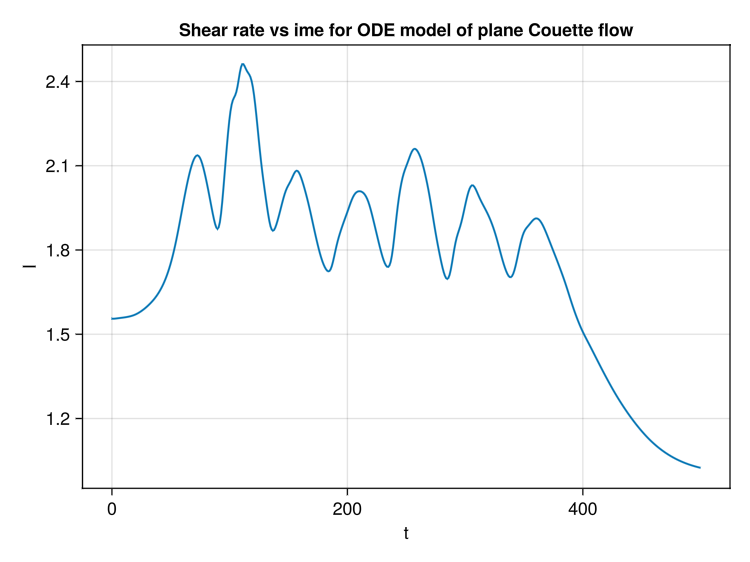

In [27]:
Nsave = 32
Δt = 1/Nsave
Nsteps = 500

#eq1file = "xeq1-Re$(R)-$J-$K-$L.asc"
#xeq1 = myreaddlm(eq1file, cc='%')

t,X = cnab2(xeq1*1.05, model, R, Δt, Nsave, Nsteps)

shear(x) = dot(model.Ψshear, x) + 1.0

I = [shear(X[:,n]) for n in 1:Nsteps+1]


f = Figure()
ax = Axis(f[1, 1], xlabel = "t", ylabel = "I", title="Shear rate vs ime for ODE model of plane Couette flow")
lines!(t, I)
f

In [16]:
lines(1:21, IDEt[:,1])

UndefVarError: UndefVarError: `IDEt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### 5. Visualize the initial condition

The `flowfield3d` function takes as arguments

  * `xeq1` a vector of coefficients `x`
  * `model.Ψ` the expansion functions
  * `2pi/α, 2pi/γ` the lengths of the box in x and z: Lx = 2pi/α, Lz = 2pi/γ
  *  24, 33, 24 specification of a 24 x 33 x 24 gird in x,y,z

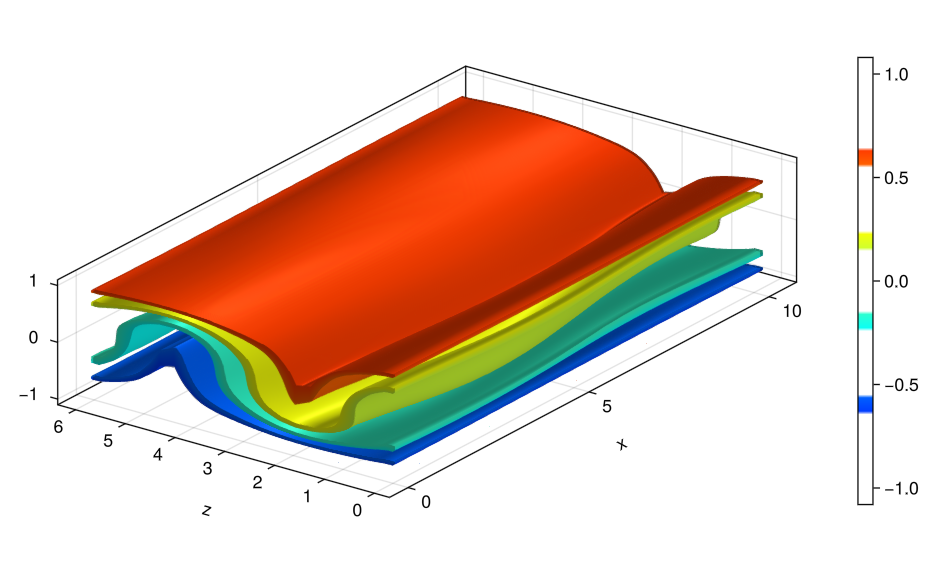

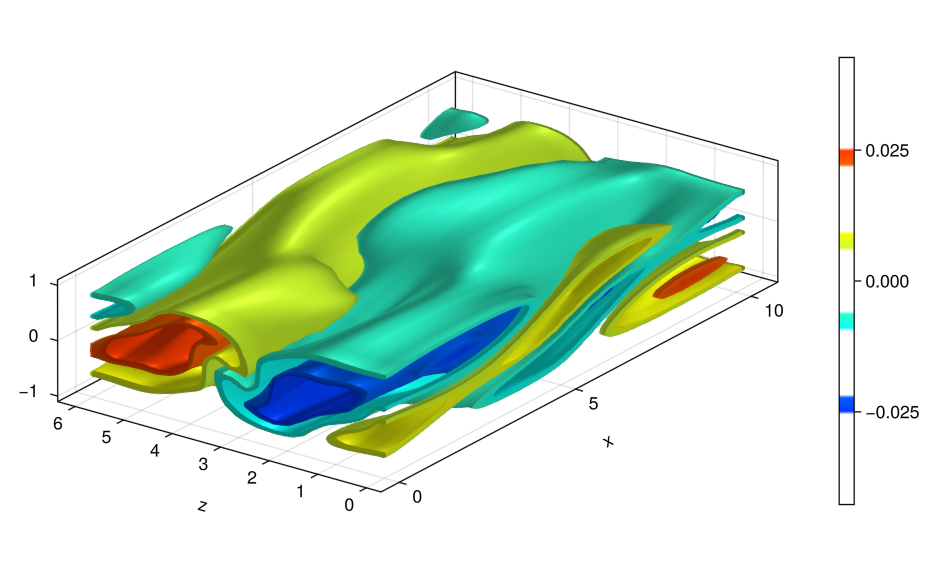

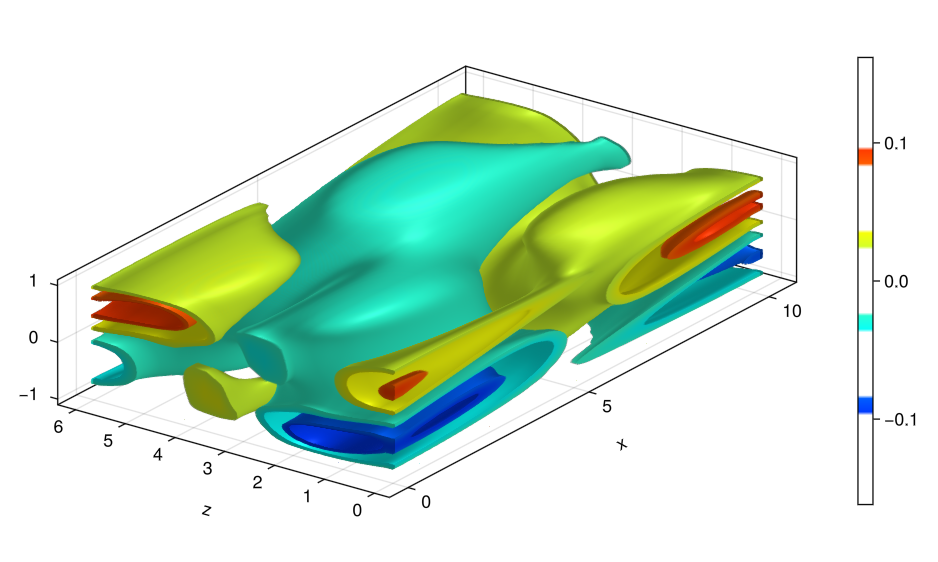

GLMakie.Screen(...)

In [28]:
display(flowfield3d("simulated_data/uEQ1_Re200_10_25_by_6_05.nc", xarrows=0, component=1, arrowcolor=:none, stride=3))
display(flowfield3d("simulated_data/uEQ1_Re200_10_25_by_6_05.nc", xarrows=0, component=2, arrowcolor=:none, stride=3))
display(flowfield3d("simulated_data/uEQ1_Re200_10_25_by_6_05.nc", xarrows=0, component=3, arrowcolor=:none, stride=3))

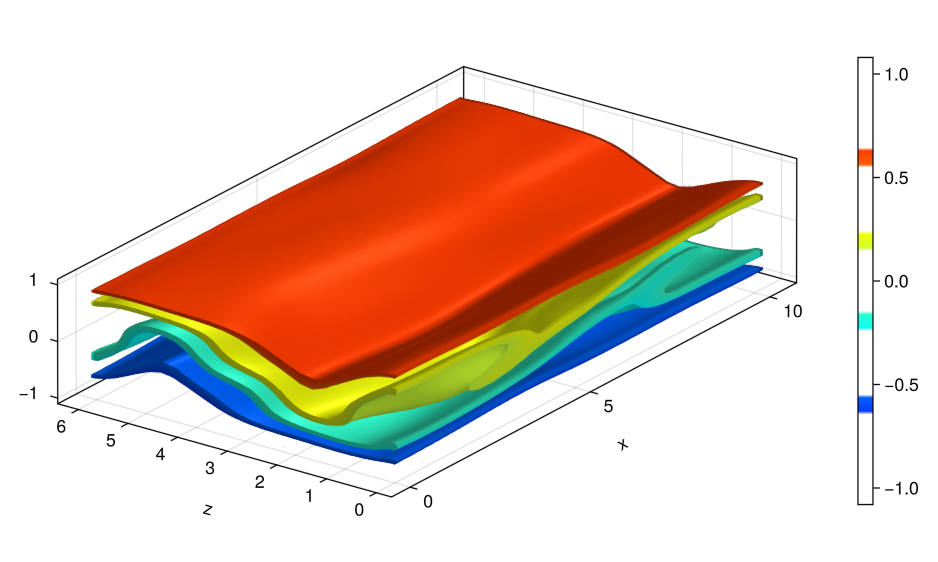

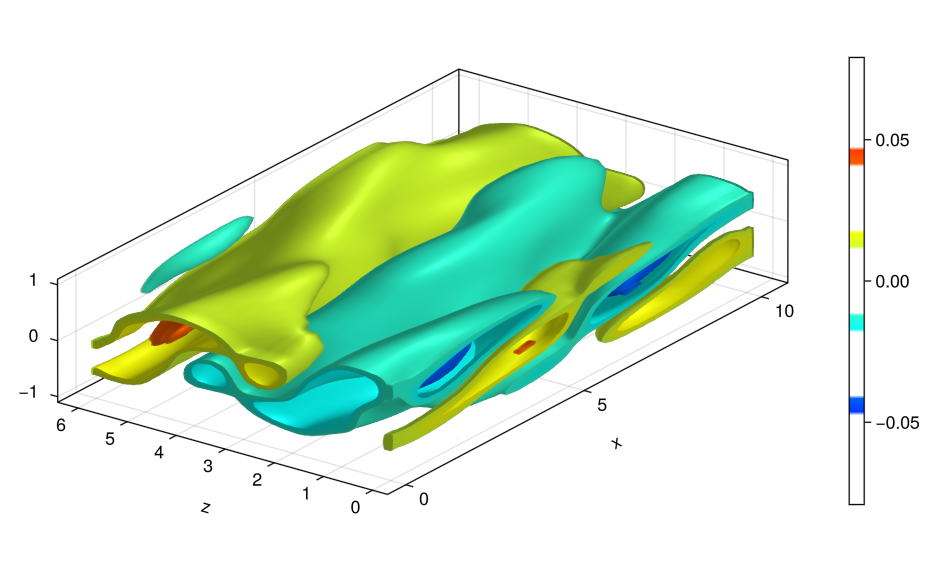

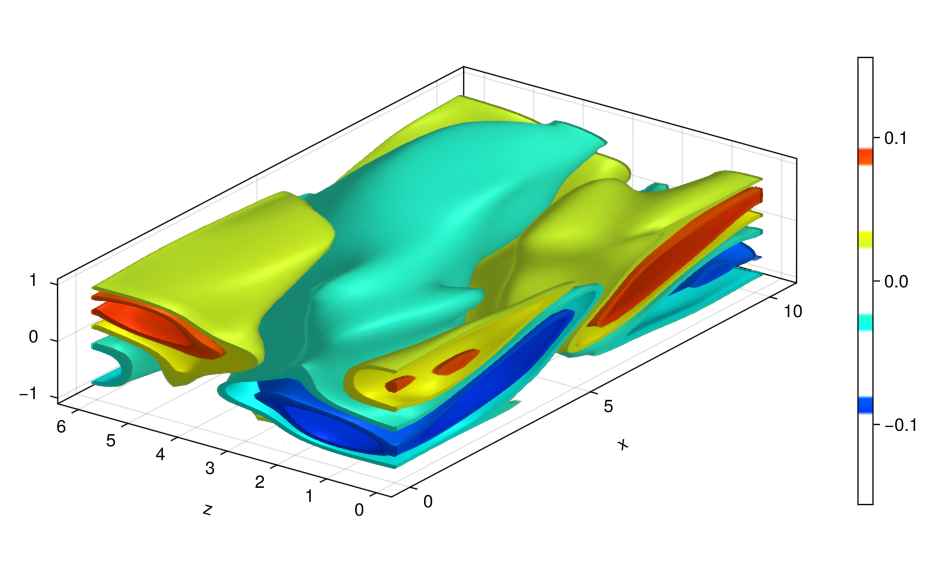

GLMakie.Screen(...)

In [29]:
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=1, arrowcolor=:none, stride=3))
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=2, arrowcolor=:none, stride=3))
display(flowfield3d(xeq1, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=3, arrowcolor=:none, stride=3))

In [51]:
x

27-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

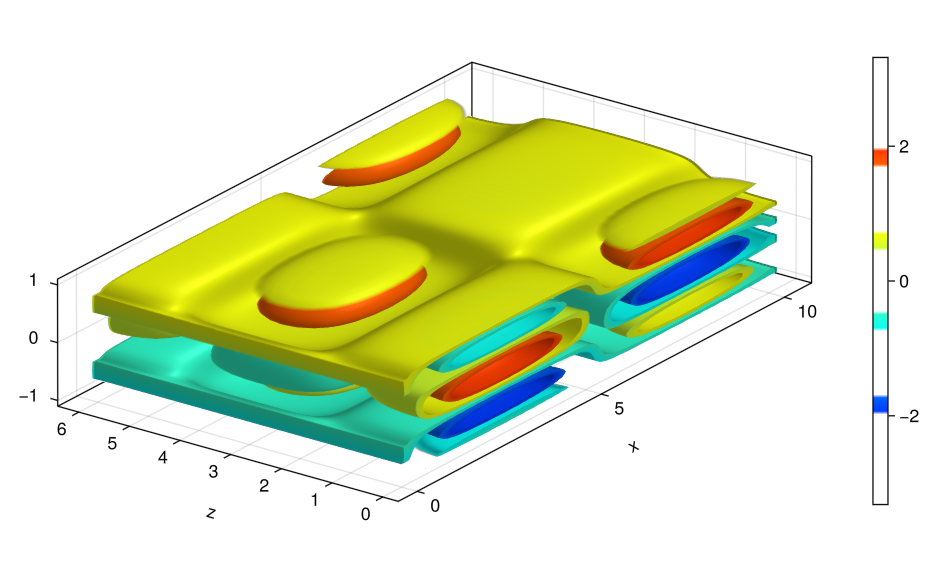

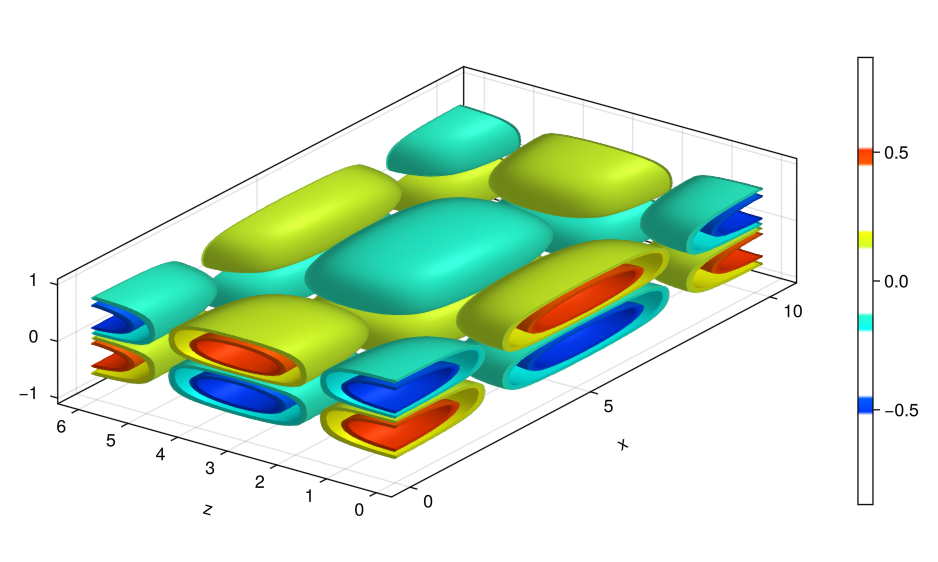

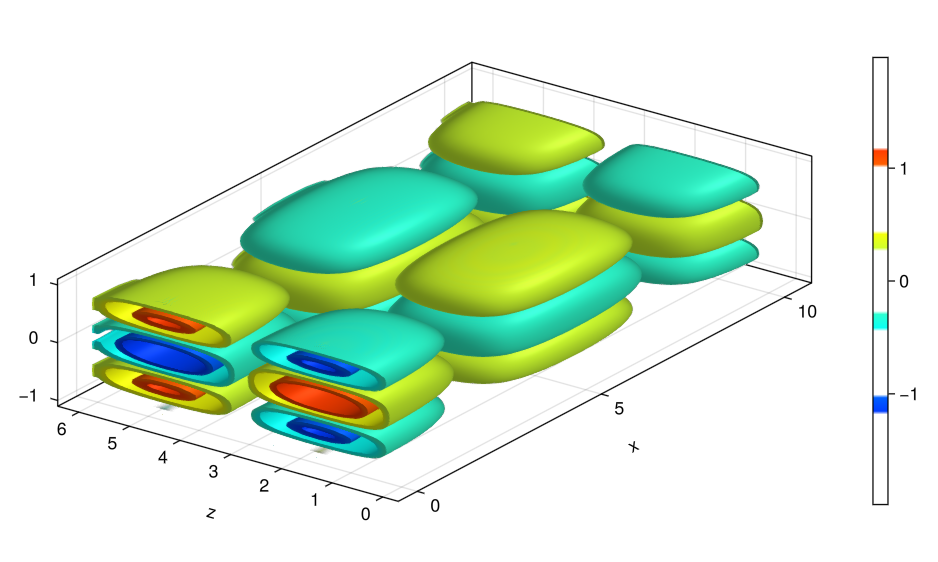

GLMakie.Screen(...)

In [24]:
x = zeros(Nmodes)
x[17] = 1.0
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=1, stride=3))
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=2, stride=3))
display(flowfield3d(x, model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, xarrows=0, component=3, stride=3))

In [121]:
u(x,y,z) = cos(x) * sin(2z) * (y - y^3/3)

u (generic function with 1 method)

### 6. Now save 3d plots of $u(x,t)$ for the first 300 time steps

You can convert these to a movie with PNG -> GIF software.

In [146]:
f = Figure()
ax = Axis(f[1,1])

nframes = 20

n_iterator = 1:nframes

record(f, "orbit1/mp4", n_iterator; framerate=10 do n
        

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\cbalusek\Desktop\CloudAtlas\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:8:49

record(f, "orbit1/mp4", n_iterator; framerate=10 do n
#                                               └ ── Expected `)` or `,`

In [ ]:
try
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-x")
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-y")
    mkdir("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-z")
catch e
    println(e)
end
for n = 1:500
    print("$n ")
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=1, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-x/frame-$(n+1000).png", f)
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=2, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-y/frame-$(n+1000).png", f)
    f = flowfield3d(X[:,n], model.Ψ, 2pi/α, 2pi/γ, 24, 33, 24, title="t=$n", component=3, xarrows=-1)
    Makie.save("Makie-Pngs/x$modNum-$α-$γ-$J-$K-$L-$R-z/frame-$(n+1000).png", f)
end
println()

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 